# CNN für den MNIST-Datensatz

Dieses Notebook dokumentiert die Entwicklung und Evaluation eines Convolutional Neural Network (CNN) zur Klassifikation handgeschriebener Ziffern auf dem MNIST-Datensatz. 

Ziel ist es, ein eigenes CNN-Modell zu entwickeln, zu trainieren und auf dem Testdatensatz anhand zentraler Metriken zu bewerten. Zusätzlich wird ein einfaches CNN aus dem Vorlesungskontext als Vergleichsmodell rekonstruiert und mit denselben Kennzahlen evaluiert.

## Inhalt des Notebooks

- Laden und Vorverarbeitung des MNIST-Datensatzes
- Definition und Training eines eigenen CNN-Modells
- Speicherung und erneutes Laden des eigenen Modells
- Evaluation anhand von Accuracy, Precision, Recall, F1-Score, FPR und FNR
- Visualisierung exemplarischer Vorhersagen und der Confusion Matrix
- Rekonstruktion und Evaluation eines Vorlesungs-CNN als Vergleichsmodell
- Gegenüberstellung der Ergebnisse beider Modelle

## Hinweis

Das Notebook dient als nachvollziehbare Dokumentation des praktischen Arbeitsprozesses und des erreichten Zwischenstands im Rahmen des Projekts.

In [40]:
# ============================================================
# 1) Import der benötigten Bibliotheken
# ============================================================
# Import der benötigten Bibliotheken für Datenverarbeitung,
# Visualisierung und Modellierung mit TensorFlow/Keras.

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Ausgabe der verwendeten TensorFlow-Version zur Dokumentation
# der Laufzeitumgebung.
print("TensorFlow-Version:", tf.__version__)

TensorFlow-Version: 2.14.0


In [41]:
# ============================================================
# 2) Vorbereitung reproduzierbarer Ergebnisse
# ============================================================
# Zur Verbesserung der Reproduzierbarkeit werden feste Zufallswerte
# für Python, NumPy und TensorFlow gesetzt.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional: Aktivierung deterministischer Operationen in TensorFlow.
# Dies kann die Reproduzierbarkeit weiter verbessern, sofern die
# verwendete Umgebung dies unterstützt.
try:
    tf.config.experimental.enable_op_determinism()
    print("Deterministische Operationen aktiviert.")
except Exception as exc:
    print("Hinweis: Determinismus konnte nicht vollständig aktiviert werden:", exc)

Deterministische Operationen aktiviert.


In [42]:
# ============================================================
# 3) Laden und Vorverarbeitung des MNIST-Datensatzes
# ============================================================
# Der MNIST-Datensatz enthält 28x28 Pixel große Graustufenbilder
# handgeschriebener Ziffern sowie die zugehörigen Klassenlabels.

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Ausgabe der ursprünglichen Form der Datensätze
print("Trainingsdaten:", x_train.shape, y_train.shape)
print("Testdaten:", x_test.shape, y_test.shape)

# Skalierung der Pixelwerte auf den Bereich [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Ergänzung einer Kanal-Dimension für die Verarbeitung im CNN
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Ausgabe der Datenform nach der Vorverarbeitung
print("Neue Form Training:", x_train.shape)
print("Neue Form Test:", x_test.shape)

Trainingsdaten: (60000, 28, 28) (60000,)
Testdaten: (10000, 28, 28) (10000,)
Neue Form Training: (60000, 28, 28, 1)
Neue Form Test: (10000, 28, 28, 1)


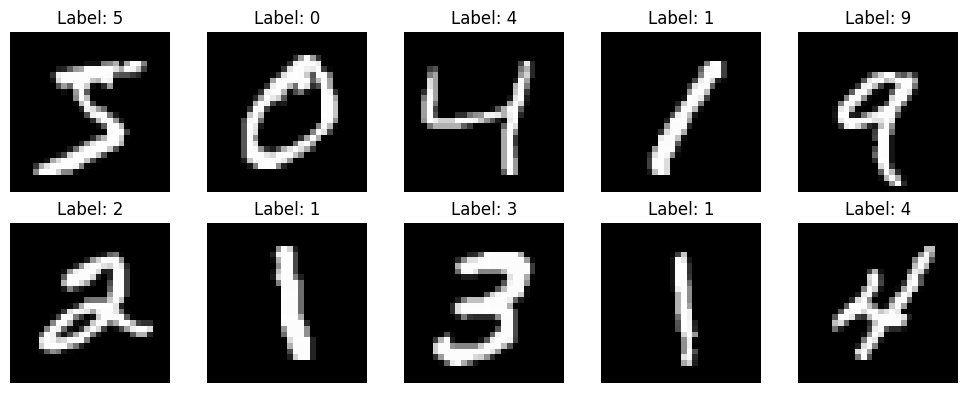

In [43]:
# ============================================================
# 4) Visualisierung von Beispielbildern aus dem Trainingsdatensatz
# ============================================================
# Zur inhaltlichen Prüfung des Datensatzes werden einige
# Beispielbilder mit ihren Klassenlabels dargestellt.

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Modellarchitektur

In diesem Abschnitt wird die für die Klassifikation handgeschriebener Ziffern auf dem MNIST-Datensatz verwendete CNN-Architektur definiert. Das Modell wird im weiteren Verlauf kompiliert, trainiert, evaluiert und anschließend gespeichert.

Die Architektur besteht aus mehreren Convolution-Schichten mit Pooling, Batch-Normalisierung und Dropout sowie einem dichten Klassifikationsblock zur finalen Vorhersage der zehn Ziffernklassen.

### Aufbau des Modells

- zwei Convolution-Blöcke mit 32 Filtern
- zwei Convolution-Blöcke mit 64 Filtern
- jeweils Batch-Normalisierung und ReLU-Aktivierung
- MaxPooling zur Reduktion der räumlichen Dimension
- Dropout zur Regularisierung
- ein Dense-Layer mit 128 Neuronen, Batch-Normalisierung und ReLU
- Ausgabelayer mit 10 Neuronen und Softmax-Aktivierung

### Compile-Konfiguration

- Optimizer: Adam
- Learning Rate: 0.00025
- Loss-Funktion: `sparse_categorical_crossentropy`
- Metrik: `accuracy`

In [44]:
# ============================================================
# 5) Modellfunktion definieren
# ============================================================
def build_cnn_model():
    """
    Erstellt ein Convolutional Neural Network (CNN) für die
    Klassifikation handgeschriebener Ziffern des MNIST-Datensatzes.

    Verwendete Architektur:
    - Input: (28, 28, 1)
    - Conv2D(32) -> BatchNormalization -> ReLU
    - Conv2D(32) -> BatchNormalization -> ReLU
    - MaxPooling -> Dropout(0.2)
    - Conv2D(64) -> BatchNormalization -> ReLU
    - Conv2D(64) -> BatchNormalization -> ReLU
    - MaxPooling -> Dropout(0.3)
    - Flatten
    - Dense(128) -> BatchNormalization -> ReLU -> Dropout(0.4)
    - Dense(10, softmax)

    Rückgabe:
        keras.Model: kompiliertes CNN-Modell zur Klassifikation
        der MNIST-Ziffern.
    """

    inputs = keras.Input(shape=(28, 28, 1), name="input_1")

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv2d"
    )(inputs)
    x = layers.BatchNormalization(name="batch_normalization")(x)
    x = layers.Activation("relu", name="activation")(x)

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv2d_1"
    )(x)
    x = layers.BatchNormalization(name="batch_normalization_1")(x)
    x = layers.Activation("relu", name="activation_1")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d")(x)
    x = layers.Dropout(0.2, name="dropout")(x)

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv2d_2"
    )(x)
    x = layers.BatchNormalization(name="batch_normalization_2")(x)
    x = layers.Activation("relu", name="activation_2")(x)

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv2d_3"
    )(x)
    x = layers.BatchNormalization(name="batch_normalization_3")(x)
    x = layers.Activation("relu", name="activation_3")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_1")(x)
    x = layers.Dropout(0.3, name="dropout_1")(x)

    x = layers.Flatten(name="flatten")(x)

    x = layers.Dense(
        units=128,
        use_bias=False,
        name="dense"
    )(x)
    x = layers.BatchNormalization(name="batch_normalization_4")(x)
    x = layers.Activation("relu", name="activation_4")(x)
    x = layers.Dropout(0.4, name="dropout_2")(x)

    outputs = layers.Dense(
        units=10,
        activation="softmax",
        name="output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="cnn_jana")

    # Kompilierung des Modells mit Adam, geeigneter
    # Verlustfunktion für Mehrklassenklassifikation
    # und Accuracy als Metrik.
    optimizer = keras.optimizers.Adam(learning_rate=0.00025)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [15]:
# ============================================================
# 6) Modell instanziieren und Architektur ausgeben
# ============================================================
# Auf Basis der zuvor definierten Funktion wird das CNN-Modell erzeugt.
# Anschließend wird eine Zusammenfassung der Modellarchitektur ausgegeben.

model = build_cnn_model()
model.summary()

Model: "cnn_jana"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        288       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 32)        128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9216      
                                                                 
 batch_normalization_1 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                         

In [18]:
# ============================================================
# 7) Definition der Callbacks für das Training
# ============================================================
# Zur Stabilisierung des Trainingsprozesses und zur automatischen
# Speicherung guter Modellzustände werden mehrere Callbacks verwendet.

# EarlyStopping beendet das Training vorzeitig, wenn sich der
# Validierungs-Loss über mehrere Epochen nicht verbessert.
# Zusätzlich werden die besten Gewichte wiederhergestellt.
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau reduziert die Lernrate automatisch, wenn die
# Validierungsleistung stagniert. Dadurch kann das Modell in späteren
# Trainingsphasen feiner angepasst werden.
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# ModelCheckpoint speichert während des Trainings die bislang beste
# Modellvariante. Aufgrund eines Kompatibilitätsproblems im aktuellen
# Setup wird hierfür das HDF5-Format (.h5) verwendet.
checkpoint = callbacks.ModelCheckpoint(
    filepath="CNN_Jana_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Zusammenfassen aller verwendeten Callbacks in einer Liste
callback_list = [early_stopping, reduce_lr, checkpoint]

In [19]:
# ============================================================
# 8) Training des Modells
# ============================================================
# Für das Training werden die Anzahl der Epochen, die Batch-Größe
# sowie der Anteil der Validierungsdaten festgelegt.

EPOCHS = 15
BATCH_SIZE = 128
VALIDATION_SPLIT = 0.1

# Training des CNN auf den Trainingsdaten.
# Ein Teil der Trainingsdaten wird zur Validierung verwendet,
# um die Modellleistung während des Trainings zu überwachen.
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callback_list,
    verbose=1
)

Epoch 1/15
422/422 [==============================] - ETA: 0s - loss: 0.1203 - accuracy: 0.9687
Epoch 1: val_accuracy improved from -inf to 0.98767, saving model to CNN_Jana_best.h5


c:\Users\florj\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


422/422 [==============================] - 259s 614ms/step - loss: 0.1203 - accuracy: 0.9687 - val_loss: 0.0450 - val_accuracy: 0.9877 - lr: 2.5000e-04
Epoch 2/15
422/422 [==============================] - ETA: 0s - loss: 0.0832 - accuracy: 0.9775
Epoch 2: val_accuracy did not improve from 0.98767
422/422 [==============================] - 289s 685ms/step - loss: 0.0832 - accuracy: 0.9775 - val_loss: 0.0399 - val_accuracy: 0.9877 - lr: 2.5000e-04
Epoch 3/15
422/422 [==============================] - ETA: 0s - loss: 0.0631 - accuracy: 0.9825
Epoch 3: val_accuracy improved from 0.98767 to 0.99067, saving model to CNN_Jana_best.h5
422/422 [==============================] - 353s 837ms/step - loss: 0.0631 - accuracy: 0.9825 - val_loss: 0.0287 - val_accuracy: 0.9907 - lr: 2.5000e-04
Epoch 4/15
422/422 [==============================] - ETA: 0s - loss: 0.0544 - accuracy: 0.9844
Epoch 4: val_accuracy improved from 0.99067 to 0.99100, saving model to CNN_Jana_best.h5
422/422 [==================

In [20]:
# ============================================================
# 9) Finales Modell speichern
# ============================================================
# Nach Abschluss des Trainings wird das finale Modell im nativen
# Keras-Format gespeichert. Dadurch wird die gewünschte Datei
# CNN_Jana.keras direkt aus dem vorliegenden Code erzeugt.

model.save("CNN_Jana.keras")
print("Modell wurde als CNN_Jana.keras gespeichert.")

Modell wurde als CNN_Jana.keras gespeichert.


## Visualisierung des Trainingsverlaufs

Zur Beurteilung des Trainingsprozesses werden im folgenden Abschnitt die Verläufe von Accuracy und Loss für Trainings- und Validierungsdaten dargestellt. Dadurch lässt sich einschätzen, wie stabil das Modell trainiert wurde und ob Hinweise auf Unter- oder Überanpassung vorliegen.

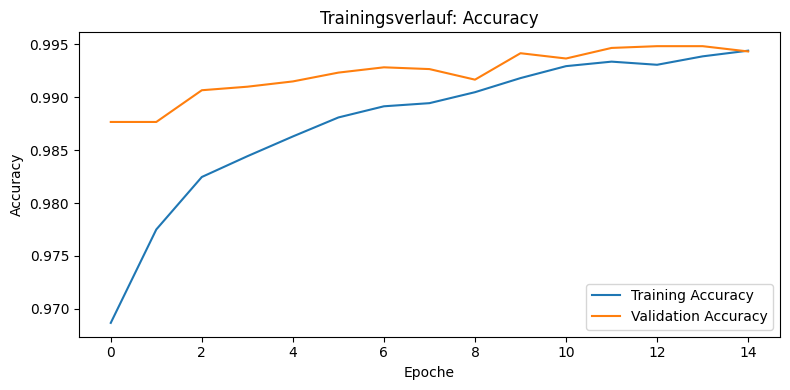

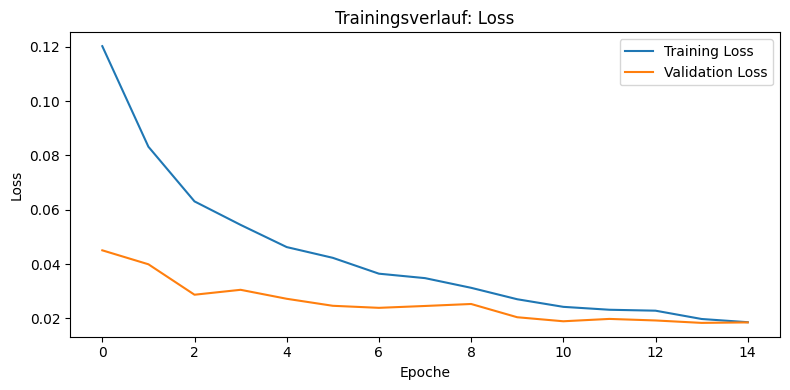

In [21]:
# ============================================================
# 10) Visualisierung des Trainingsverlaufs
# ============================================================
# Zur Beurteilung des Trainingsprozesses werden die Verläufe von
# Accuracy und Loss für Trainings- und Validierungsdaten dargestellt.

history_dict = history.history

# Darstellung der Accuracy-Verläufe
plt.figure(figsize=(8, 4))
plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.title("Trainingsverlauf: Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Darstellung der Loss-Verläufe
plt.figure(figsize=(8, 4))
plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Trainingsverlauf: Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 11) Finales Modell speichern
# ============================================================
# Nach Abschluss des Trainings wird das finale Modell im nativen
# Keras-Format gespeichert. Damit wird die gewünschte Modelldatei
# direkt aus dem vorliegenden Code erzeugt.

final_model_path = "CNN_Jana.keras"
model.save(final_model_path)

print("Modell gespeichert unter:", final_model_path)
print("Bestes Checkpoint-Modell:", "CNN_Jana_best.h5")

Modell gespeichert unter: CNN_Jana.keras
Bestes Checkpoint-Modell: CNN_Jana_best.h5


In [23]:
# ============================================================
# 12) Gespeichertes Modell testweise wieder laden
# ============================================================
# Zur Kontrolle wird die zuvor gespeicherte Keras-Datei erneut geladen.
# Dadurch lässt sich prüfen, ob das Modell korrekt gespeichert wurde.

loaded_model = keras.models.load_model("CNN_Jana.keras")
loaded_model.summary()

Model: "cnn_jana"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        288       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 32)        128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9216      
                                                                 
 batch_normalization_1 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                         

## Qualitative Überprüfung des Modells

Im folgenden Abschnitt werden exemplarische Vorhersagen des gespeicherten Modells auf Testdaten visualisiert. Dadurch lässt sich qualitativ prüfen, ob die vorhergesagten Klassen mit den tatsächlichen Labels übereinstimmen.

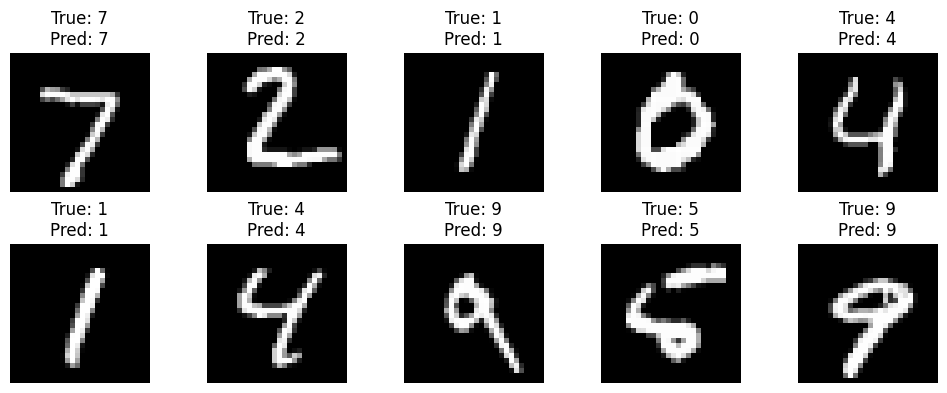

In [24]:
# ============================================================
# 13) Exemplarische Vorhersagen auf Testdaten visualisieren
# ============================================================
# Zur qualitativen Überprüfung des gespeicherten Modells werden
# für einige Testbilder Vorhersagen erzeugt und den wahren Labels
# gegenübergestellt.

pred_probs = loaded_model.predict(x_test[:10], verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"True: {y_test[i]}\nPred: {pred_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Quantitative Evaluation des Modells

Im folgenden Abschnitt wird das gespeicherte Modell anhand zentraler Kennzahlen auf dem Testdatensatz bewertet. Dazu werden Accuracy, Precision, Recall, F1-Score, FPR und FNR berechnet. Ergänzend werden auch Parameteranzahl und Modellgröße berücksichtigt.

In [ ]:
# ============================================================
# 14) Finale Evaluation des Modells auf dem Testdatensatz
#    
# ============================================================

import os
import numpy as np

# ------------------------------------------------------------
# Wahre Klassenlabels bestimmen
# ------------------------------------------------------------
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# ------------------------------------------------------------
# Vorhersagen auf dem gesamten Testset
# ------------------------------------------------------------
y_pred_probs = loaded_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------------------------------------------------
# Accuracy berechnen
# ------------------------------------------------------------
accuracy = np.mean(y_true == y_pred)

# ------------------------------------------------------------
# Confusion Matrix manuell erstellen
# ------------------------------------------------------------
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(y_true, y_pred):
    cm[true_label, pred_label] += 1

# ------------------------------------------------------------
# Precision, Recall, F1 pro Klasse
# ------------------------------------------------------------
precisions = []
recalls = []
f1_scores = []
fprs = []
fnrs = []

for i in range(num_classes):
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    precision_i = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_i = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_i = (2 * precision_i * recall_i / (precision_i + recall_i)
            if (precision_i + recall_i) > 0 else 0)
    fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr_i = FN / (FN + TP) if (FN + TP) > 0 else 0

    precisions.append(precision_i)
    recalls.append(recall_i)
    f1_scores.append(f1_i)
    fprs.append(fpr_i)
    fnrs.append(fnr_i)

# Makro-Mittelwerte
precision_macro = np.mean(precisions)
recall_macro = np.mean(recalls)
f1_macro = np.mean(f1_scores)
fpr_macro = np.mean(fprs)
fnr_macro = np.mean(fnrs)

# ------------------------------------------------------------
# Modellinformationen
# ------------------------------------------------------------
param_count = loaded_model.count_params()

model_path = "CNN_Jana.keras"   # ggf. anpassen
model_size_kb = os.path.getsize(model_path) / 1024

# ------------------------------------------------------------
# Ausgabe
# ------------------------------------------------------------
print("===== Finale Testset-Evaluation =====")
print(f"Accuracy:             {accuracy:.4f}")
print(f"Precision (macro):    {precision_macro:.4f}")
print(f"Recall (macro):       {recall_macro:.4f}")
print(f"F1-Score (macro):     {f1_macro:.4f}")
print(f"False Positive Rate:  {fpr_macro:.4f}")
print(f"False Negative Rate:  {fnr_macro:.4f}")
print(f"Parameteranzahl:      {param_count}")
print(f"Modellgröße:          {model_size_kb:.2f} KB")

===== Finale Testset-Evaluation =====
Accuracy:             0.9953
Precision (macro):    0.9953
Recall (macro):       0.9952
F1-Score (macro):     0.9953
False Positive Rate:  0.0005
False Negative Rate:  0.0048
Parameteranzahl:      468778
Modellgröße:          5575.53 KB


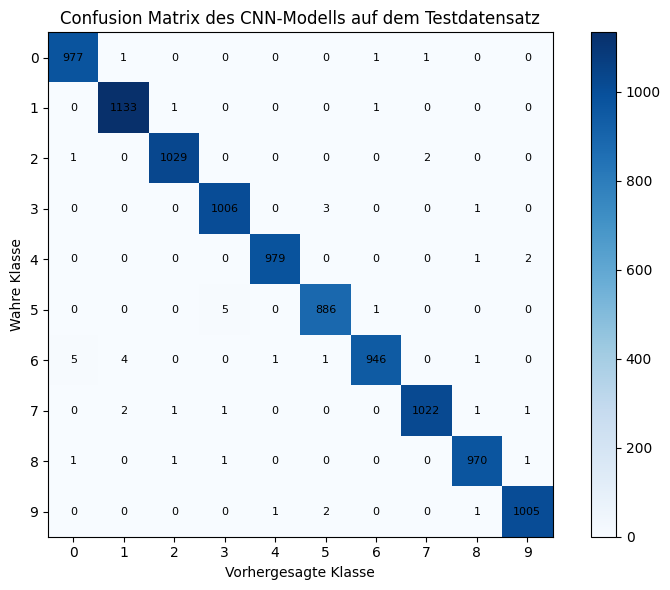

In [27]:
# ============================================================
# 15) Confusion Matrix visualisieren
# ============================================================
# Die Confusion Matrix zeigt, welche Ziffern korrekt bzw.
# fälschlich klassifiziert wurden. Sie ergänzt die Kennzahlen
# aus der finalen Evaluation um eine klassenbezogene Sicht.

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix des CNN-Modells auf dem Testdatensatz")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Wahre Klasse")
plt.colorbar()

# Achsenbeschriftung 0 bis 9
classes = np.arange(10)
plt.xticks(classes)
plt.yticks(classes)

# Werte in die Matrix schreiben
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="black", fontsize=8
        )

plt.tight_layout()
plt.show()

## Vergleich mit einem Vorlesungs-CNN

Zusätzlich zum eigenen Modell wird ein einfacheres CNN aus dem Vorlesungskontext als Vergleichsmodell betrachtet. Da das ursprünglich gespeicherte Modell aufgrund von Versionsunterschieden nicht direkt geladen werden konnte, wurde die zugrunde liegende Architektur rekonstruiert, neu trainiert und anschließend mit denselben Kennzahlen evaluiert.

In [28]:
# ============================================================
# 16) Pfad zum Vorlesungsmodell festlegen
# ============================================================

lecture_model_path = r"C:\Users\florj\OneDrive\Desktop\KI\model_simple_conv.keras"

print("Verwendeter Pfad:", lecture_model_path)

Verwendeter Pfad: C:\Users\florj\OneDrive\Desktop\KI\model_simple_conv.keras


In [29]:
# ============================================================
# 17) Existenz der Datei prüfen
# ============================================================

import os

print("Datei gefunden:", os.path.exists(lecture_model_path))

Datei gefunden: True


In [31]:
# ============================================================
# 18) Vorlesungsmodell laden (angepasster Versuch)
# ============================================================

try:
    lecture_model = tf.keras.models.load_model(
        lecture_model_path,
        compile=False
    )
    print("Vorlesungsmodell erfolgreich geladen.")
    lecture_model.summary()

except Exception as e:
    print("Fehler beim Laden des Vorlesungsmodells:")
    print(e)

Fehler beim Laden des Vorlesungsmodells:
Could not deserialize class 'Functional' because its parent module keras.src.models.functional cannot be imported. Full object config: {'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {'name': 'simple_cnn', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 28, 28, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_image'}, 'registered_name': None, 'name': 'input_image', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'filters': 32, 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.in

In [32]:
# ============================================================
# 19) Vorlesungs-CNN manuell nachbauen
# ============================================================
# Das gespeicherte Vorlesungsmodell ist aufgrund von Keras-
# Versionsunterschieden nicht direkt ladbar. Deshalb wird die
# Architektur anhand der Modellkonfiguration manuell rekonstruiert.

from tensorflow.keras import layers, models

lecture_model = models.Sequential([
    layers.Input(shape=(28, 28, 1), name="input_image"),
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_1"
    ),
    layers.MaxPooling2D(
        pool_size=(3, 3),
        strides=(3, 3),
        name="maxpool_1"
    ),
    layers.Flatten(name="flatten"),
    layers.Dense(64, activation="relu", name="dense_1"),
    layers.Dense(10, activation="softmax", name="output")
], name="simple_cnn")

lecture_model.summary()

Model: "simple_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_1 (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 8, 8, 32)          0         
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 64)                131136    
                                                                 
 output (Dense)              (None, 10)                650       
                                                                 
Total params: 132106 (516.04 KB)
Trainable params: 132106 (516.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [33]:
# ============================================================
# 20) Vorlesungs-CNN kompilieren
# ============================================================
# Die Verlustfunktion wird passend zum Label-Format gewählt.

if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    lecture_loss = "categorical_crossentropy"
else:
    lecture_loss = "sparse_categorical_crossentropy"

lecture_model.compile(
    optimizer="adam",
    loss=lecture_loss,
    metrics=["accuracy"]
)

print("Verwendete Loss-Funktion:", lecture_loss)

Verwendete Loss-Funktion: sparse_categorical_crossentropy


In [35]:
# ============================================================
# 21) Vorlesungs-CNN trainieren
# ============================================================

history_lecture = lecture_model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
422/422 [==============================] - 65s 130ms/step - loss: 0.3284 - accuracy: 0.9067 - val_loss: 0.0982 - val_accuracy: 0.9738
Epoch 2/10
422/422 [==============================] - 63s 148ms/step - loss: 0.0954 - accuracy: 0.9715 - val_loss: 0.0847 - val_accuracy: 0.9755
Epoch 3/10
422/422 [==============================] - 43s 102ms/step - loss: 0.0676 - accuracy: 0.9798 - val_loss: 0.0597 - val_accuracy: 0.9843
Epoch 4/10
422/422 [==============================] - 27s 64ms/step - loss: 0.0541 - accuracy: 0.9836 - val_loss: 0.0538 - val_accuracy: 0.9863
Epoch 5/10
422/422 [==============================] - 26s 62ms/step - loss: 0.0451 - accuracy: 0.9860 - val_loss: 0.0481 - val_accuracy: 0.9868
Epoch 6/10
422/422 [==============================] - 29s 68ms/step - loss: 0.0380 - accuracy: 0.9887 - val_loss: 0.0499 - val_accuracy: 0.9872
Epoch 7/10
422/422 [==============================] - 27s 63ms/step - loss: 0.0330 - accuracy: 0.9899 - val_loss: 0.0484 - val_accura

In [36]:
# ============================================================
# 22) Vorlesungs-CNN evaluieren
# ============================================================

import numpy as np

# Wahre Klassenlabels bestimmen
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true_lecture = np.argmax(y_test, axis=1)
else:
    y_true_lecture = y_test

# Vorhersagen des Vorlesungsmodells
y_pred_probs_lecture = lecture_model.predict(x_test, verbose=0)
y_pred_lecture = np.argmax(y_pred_probs_lecture, axis=1)

# Confusion Matrix manuell erstellen
num_classes = 10
cm_lecture = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(y_true_lecture, y_pred_lecture):
    cm_lecture[true_label, pred_label] += 1

# Accuracy
accuracy_lecture = np.mean(y_true_lecture == y_pred_lecture)

# Precision, Recall, F1, FPR, FNR pro Klasse
precisions_lecture = []
recalls_lecture = []
f1_scores_lecture = []
fprs_lecture = []
fnrs_lecture = []

for i in range(num_classes):
    TP = cm_lecture[i, i]
    FP = np.sum(cm_lecture[:, i]) - TP
    FN = np.sum(cm_lecture[i, :]) - TP
    TN = np.sum(cm_lecture) - (TP + FP + FN)

    precision_i = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall_i = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_i = (2 * precision_i * recall_i / (precision_i + recall_i)
            if (precision_i + recall_i) > 0 else 0)
    fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0
    fnr_i = FN / (FN + TP) if (FN + TP) > 0 else 0

    precisions_lecture.append(precision_i)
    recalls_lecture.append(recall_i)
    f1_scores_lecture.append(f1_i)
    fprs_lecture.append(fpr_i)
    fnrs_lecture.append(fnr_i)

precision_macro_lecture = np.mean(precisions_lecture)
recall_macro_lecture = np.mean(recalls_lecture)
f1_macro_lecture = np.mean(f1_scores_lecture)
fpr_macro_lecture = np.mean(fprs_lecture)
fnr_macro_lecture = np.mean(fnrs_lecture)

print("===== Finale Testset-Evaluation: Vorlesungs-CNN =====")
print(f"Accuracy:             {accuracy_lecture:.4f}")
print(f"Precision (macro):    {precision_macro_lecture:.4f}")
print(f"Recall (macro):       {recall_macro_lecture:.4f}")
print(f"F1-Score (macro):     {f1_macro_lecture:.4f}")
print(f"False Positive Rate:  {fpr_macro_lecture:.4f}")
print(f"False Negative Rate:  {fnr_macro_lecture:.4f}")
print(f"Parameteranzahl:      {lecture_model.count_params()}")

===== Finale Testset-Evaluation: Vorlesungs-CNN =====
Accuracy:             0.9869
Precision (macro):    0.9870
Recall (macro):       0.9868
F1-Score (macro):     0.9868
False Positive Rate:  0.0015
False Negative Rate:  0.0132
Parameteranzahl:      132106


In [37]:
# ============================================================
# 23) Vergleich der beiden CNN-Modelle
# ============================================================

print("===== Vergleich: Eigenes CNN vs. Vorlesungs-CNN =====")
print(f"{'Metrik':<25} {'Eigenes CNN':<15} {'Vorlesungs-CNN':<15}")
print("-" * 55)
print(f"{'Accuracy':<25} {accuracy:.4f}{'':<9} {accuracy_lecture:.4f}")
print(f"{'Precision (macro)':<25} {precision_macro:.4f}{'':<9} {precision_macro_lecture:.4f}")
print(f"{'Recall (macro)':<25} {recall_macro:.4f}{'':<9} {recall_macro_lecture:.4f}")
print(f"{'F1-Score (macro)':<25} {f1_macro:.4f}{'':<9} {f1_macro_lecture:.4f}")
print(f"{'False Positive Rate':<25} {fpr_macro:.4f}{'':<9} {fpr_macro_lecture:.4f}")
print(f"{'False Negative Rate':<25} {fnr_macro:.4f}{'':<9} {fnr_macro_lecture:.4f}")
print(f"{'Parameteranzahl':<25} {loaded_model.count_params():<15} {lecture_model.count_params():<15}")

===== Vergleich: Eigenes CNN vs. Vorlesungs-CNN =====
Metrik                    Eigenes CNN     Vorlesungs-CNN 
-------------------------------------------------------
Accuracy                  0.9953          0.9869
Precision (macro)         0.9953          0.9870
Recall (macro)            0.9952          0.9868
F1-Score (macro)          0.9953          0.9868
False Positive Rate       0.0005          0.0015
False Negative Rate       0.0048          0.0132
Parameteranzahl           468778          132106         


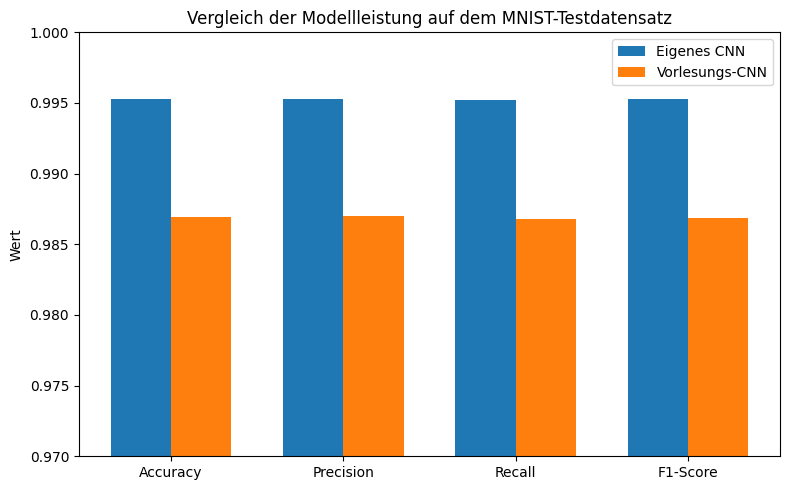

In [38]:
# ============================================================
# 23) Vergleichsplot der wichtigsten Kennzahlen
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
own_values = [accuracy, precision_macro, recall_macro, f1_macro]
lecture_values = [accuracy_lecture, precision_macro_lecture, recall_macro_lecture, f1_macro_lecture]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, own_values, width, label="Eigenes CNN")
plt.bar(x + width/2, lecture_values, width, label="Vorlesungs-CNN")

plt.xticks(x, metrics_names)
plt.ylim(0.97, 1.00)
plt.ylabel("Wert")
plt.title("Vergleich der Modellleistung auf dem MNIST-Testdatensatz")
plt.legend()
plt.tight_layout()
plt.show()

## Zusammenfassung der Ergebnisse

Im Rahmen dieses Notebooks wurde ein eigenes CNN zur Klassifikation handgeschriebener Ziffern auf dem MNIST-Datensatz entwickelt, trainiert und evaluiert. Zusätzlich wurde ein einfacheres CNN aus dem Vorlesungskontext rekonstruiert und als Vergleichsmodell herangezogen.

Die Ergebnisse zeigen, dass das eigene CNN auf dem Testdatensatz bessere Kennzahlen als das Vorlesungs-CNN erreicht. Gleichzeitig weist es jedoch eine höhere Modellkomplexität auf. Insgesamt konnte damit ein leistungsfähiges Modell für die MNIST-Klassifikation entwickelt und im Vergleich zum Vorlesungsmodell eingeordnet werden.